[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1VWduZ0c5i6VXgypRWwWnKP4N1dMRHrAN)


# Предсказание цен на недвижимость

**Обзор доступных данных**

В выборке 15129 наблюдений и 16 переменных.
Таким образом, про каждый из 15129 объектов недвижимости мы знаем значения 16 их характеристик (число спален, оценка состояния риелтором, наличие вида на воду и т.п.)






Данные содержат два типа переменных:

* Целевая: **Целевая. Цена**
* Остальные переменные: **15 переменных, могут использоваться для прогноза целевой переменной.**

## 1. Загрузить данные для обучения

**Шаг 1.1. Загружаем библиотеки**

In [1]:
import pandas as pd # загружаем библиотеку и для простоты обращения в коде называем её сокращенно pd

In [2]:
import matplotlib.pyplot as plt # загружаем библиотеку и для простоты обращения в коде называем её сокращенно plt

**Шаг 1.2. Загрузим данные**

Для решения задачи мы будем использовать данные.  Загружаем данные по ссылке из интернета с помощие команды !wget. Для того, чтобы игнорировать сообщения в процессе загрузки используем  команду %%capture в первой строке.

In [3]:
%%capture
!wget https://www.dropbox.com/s/afwb0tnqm9izxha/predict_house_price_training_data.xlsx


In [4]:
data = pd.read_excel('predict_house_price_training_data.xlsx') # загружаем таблицу в переменную data

In [5]:
data.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,830000,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,385000,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,610000,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,550000,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,1300000,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


In [6]:
data.shape

(15129, 16)

# 2. Обработать данные перед обучением модели

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15129 entries, 0 to 15128
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         15129 non-null  int64  
 1   Спальни              15129 non-null  int64  
 2   Ванные               15129 non-null  float64
 3   Жилая площадь        15129 non-null  int64  
 4   Общая площадь        15129 non-null  int64  
 5   Количество этажей    15129 non-null  float64
 6   Вид на воду          15129 non-null  int64  
 7   Просмотрены ранее    15129 non-null  int64  
 8   Состояние            15129 non-null  int64  
 9   Оценка риелтора      15129 non-null  int64  
 10  Площадь без подвала  15129 non-null  int64  
 11  Площадь подвала      15129 non-null  int64  
 12  Год постройки        15129 non-null  int64  
 13  Год реновации        15129 non-null  int64  
 14  Широта               15129 non-null  float64
 15  Долгота              15129 non-null 

**Шаг 2.2. Работаем с целевой переменной**

*Какая переменная целевая?*

В данном случае по условию задачи мы должны прогнозировать стоимость, поэтому целевая переменная - это цена.

In [8]:
y = data['Целевая.Цена']

Посмотрим на среднюю стоимость дома

In [9]:
y.mean()

538795.2958556415

Зададим входы модели

In [10]:
X = data.drop('Целевая.Цена', axis=1)

**Разбиваем исходные данные на обучающую и тестовую выборку**. Доли общей выборки для обучения и тестирования обычно 80% и 20% соотвественно. Любые разумные числа подходят, если для обучения используется достаточно много данных (обычно больше 50%), но и для тестирования что-то остается (10% и больше).

In [11]:
from sklearn.model_selection import train_test_split
# Разбиение набора данных на обучающую и тестовую части в соотношении 4:1.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=21)

Так как данные измерены в разных шкалах, выполним нормировку данных, переведя все входные признаки в один диапазон

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##   3. Обучить модель на обучающей выборке

**Шаг 3.1. Выбираем метод, который будем использовать**

Проще всего начать с простых методов.

* Линейная регрессия *linear regression*




Для корректной работы с методами построения моделей в python требуется загрузить специальную библиотеку
**sklearn**, программную библиотеку на языке python для для машинного обучения и анализа данных.

Мы импортируем  модуль из этой библиотеки:
 * *linear_model* - тут находятся все линейные модели


In [13]:
from sklearn import linear_model

In [14]:
linear_regression_model = linear_model.LinearRegression() # создаем модель

**Шаг 3.2. Обучить модель**

Теперь, когда мы создали прототип  модели, можем его обучить с помощью обучающей выборки.

Для этого вызываем метод **fit()** у каждой модели и передаем ему на вход два аргумента:
таблицу входных признаков и столбец значений целевой переменной - (X_train,  y_train)

In [15]:
linear_regression_model.fit(X_train, y_train)

LinearRegression()

In [16]:
linear_regression_model.score(X_test, y_test)

0.692424990673975


* Мы получили обученную модель.
* Теперь необходимо провалидировать модель на новых тестовых данных.

# 5. Провалидировать модель на тестовой выборке


Получим прогноз целевой переменной на тестовых данных для модели линейной регрессии .

Для этого вызовем  метод **predict()**, в качестве аргумента передадим *X_test*.

In [17]:
test_predictions = linear_regression_model.predict(X_test)

Качество регрессионных моделей оценим двумя способами:
1. Сравним визуально прогнозы с настоящими ценами (тестовые с предсказанием)
2. Сравним метрики качества

Визуализируем прогноз линейной модели и настоящие значения из тестовой выборки.


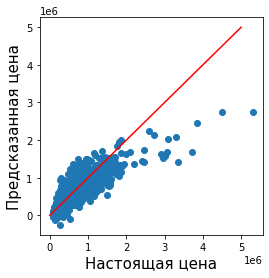

In [18]:
plt.figure(figsize=(4, 4))
plt.scatter(y_test, test_predictions) # рисуем точки, соответствущие парам настоящее значение - прогноз
plt.plot([0,  5000000], [0, 5000000], color='red') # рисуем прямую, на которой предсказания и настоящие значения совпадают
plt.xlabel('Настоящая цена', fontsize=15)
plt.ylabel('Предсказанная цена', fontsize=15);

Видим, что предасказанные цены не совсем совпадают с настоящими


Для корректного подсчета метрик качества модели в python требуется загрузить их из библиотеки **sklearn**.

Мы используем три метрики качества:

*   *R^2*- точность модели (коэффициент детерминации)- чем ближе к 1, тем лучше
* *mean_absolute_error* - средняя абсолютная ошибка $|y_i - \hat{y}_i|$ - чем меньше, тем лучше
* *mean_squared_error* - средняя квадратичная ошибка $(y_i - \hat{y}_i)^2$ - чем меньше, тем лучше


Найдем сначала точность

In [19]:
r2=linear_regression_model.score(X_test,y_test)
print(r2)

0.692424990673975


Считается, что точность модели хорошая, если R^2 больше, чем 0.8. В данном случае точность модели получилась не очень высокая.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

Подсчитаем теперь ошибки для линейной модели.

Для этого вызовем методы **mean_absolute_error()** и **mean_squared_error()**. На вход им передается столбец настоящих значений *y_test* и столбец значений, предсказанных моделью линейной регрессии *test_predictions*.

In [21]:
mae_linear_model = mean_absolute_error(y_test, test_predictions)
mse_linear_model = mean_squared_error(y_test, test_predictions)

Теперь напечатаем полученные ошибки. Обычно смотрят на корень из среднеквадратичной ошибки, RMSE.

In [22]:
print('MAE:', mae_linear_model,'RMSE:',   mse_linear_model**0.5)



MAE: 124458.83371356507 RMSE: 192887.0462754173


У нас получилось, что предсказывая цену дома, наша модель в среднем ошибается на 124 458 долларов (при средней стоимости 538 795 долларов) - что, конечно, много


Исследуем, какие признаки сильнее всего влияют на цену дома

In [23]:
yy=linear_regression_model.coef_

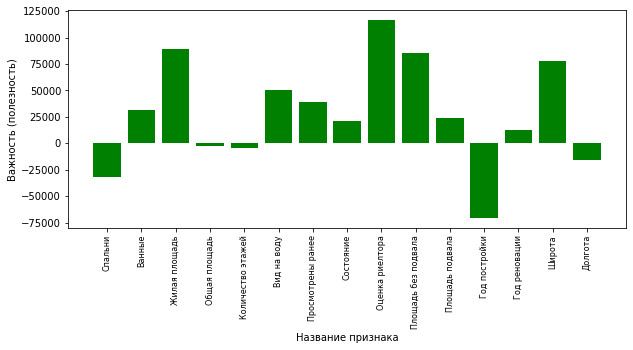

In [24]:
plt.figure(figsize=(10, 4))
plt.ylabel('Важность (полезность)')
plt.xlabel('Название признака')
plt.bar(X.columns,yy, color='green')
plt.xticks(rotation=90, fontsize=8)
plt.show()

Чем больше (по модулю) столбик на графике, тем сильнее признак влияет на цену. Если важность положительная, то, чем больше значение признака, тем выше цена. Если отрицательная, то, чем больше значение признака, тем меньше цена
